In [1]:
from idlelib.rpc import response_queue

import dnnlpy
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import Tensor

dnnlpy.set_matplotlib_format('svg')
print("PyTorch version: ", torch.__version__)

PyTorch version:  2.13.0+cpu


In [3]:
"""
从第一个局部窗口开始
    - 每个输出元素的窗口只依赖输入的一个局部窗口
    - 所有位置的都是使用完全相同的卷积参数
"""


def corr2d(x: Tensor, kernel: Tensor) -> Tensor:
    if x.ndim != 2 or kernel.ndim != 2:
        raise ValueError('Kernel size must be 2 or greater')

    K_h, K_w = kernel.size()
    h = x.size(0) - K_h + 1
    w = x.size(1) - K_w + 1

    if h < 0 or w < 0:
        raise ValueError('Kernel size must be greater or equal to zero')

    out_put = x.new_empty((h, w))

    for i in range(h):
        for j in range(w):
            window = x[i:i + K_h, j:j + K_w]
            out_put[i, j] = torch.sum(window * kernel)
    return out_put


x = torch.arange(9, dtype=torch.float32).view(3, 3)
kernel = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
y = corr2d(x, kernel)
print("Input:", x, sep='\n')
print("kernel:", kernel, sep='\n')
print("Output:", y, sep='\n')




Input:
tensor([[0., 1., 2.],
        [3., 4., 5.],
        [6., 7., 8.]])
kernel:
tensor([[0., 1.],
        [2., 3.]])
Output:
tensor([[19., 25.],
        [37., 43.]])


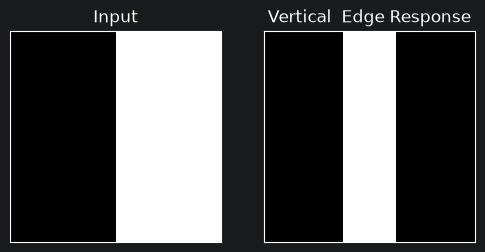

In [5]:
"""
卷积核在检测什么
"""
image = torch.zeros(10, 10)
image[:, 5:] = 1.0

kernel = torch.tensor([
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0],
    [-1.0, 0.0, 1.0]
])

response = corr2d(image, kernel)

fig = plt.figure(1, figsize=(6, 3))
ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(image, cmap='gray', vmin=0, vmax=1)
ax1.set_yticks([])
ax1.set_xticks([])
ax1.set_title('Input')
ax2 = fig.add_subplot(1, 2, 2)
ax2.imshow(response, cmap='gray', vmin=0, vmax=1)
ax2.set_yticks([])
ax2.set_xticks([])
ax2.set_title('Vertical  Edge Response')
plt.show()

In [6]:
"""
padding:控制边界输出尺寸
    - 二维padding 的顺序是  left,right,top,bottom
"""
x = torch.arange(1, 10, dtype=torch.float32)
x = x.view(1, 1, 3, 3)
padded = F.pad(x, pad=(1, 1, 1, 1))

print("Original:", x, sep='\n')
print("Padded:", padded, sep='\n')

Original:
tensor([[[[1., 2., 3.],
          [4., 5., 6.],
          [7., 8., 9.]]]])
Padded:
tensor([[[[0., 0., 0., 0., 0.],
          [0., 1., 2., 3., 0.],
          [0., 4., 5., 6., 0.],
          [0., 7., 8., 9., 0.],
          [0., 0., 0., 0., 0.]]]])


In [8]:
"""
Stride:控制卷积核移动过的步长
    stride大于1 的卷积同时完成了两个计算
        - 提取局部特征
        - 对特征图实现了下采样
"""
x = torch.arange(1, 26, dtype=torch.float32).view(1, 1, 5, 5)
kernel = torch.ones(1, 1, 3, 3)
stride1 = F.conv2d(x, kernel, stride=1)
stride2 = F.conv2d(x, kernel, stride=2)
print("Input:", x, sep='\n')
print("Output shape with Stride1:", stride1.shape, sep='\n')
print("Output shape with Stride2:", stride2.shape, sep='\n')
print("Output with stride1:", stride1[0, 0], sep='\n')
print("Output with stride2:", stride2[0, 0], sep='\n')
print("Stride1:", stride1, sep='\n')


Input:
tensor([[[[ 1.,  2.,  3.,  4.,  5.],
          [ 6.,  7.,  8.,  9., 10.],
          [11., 12., 13., 14., 15.],
          [16., 17., 18., 19., 20.],
          [21., 22., 23., 24., 25.]]]])
Output shape with Stride1:
torch.Size([1, 1, 3, 3])
Output shape with Stride2:
torch.Size([1, 1, 2, 2])
Output with stride1:
tensor([[ 63.,  72.,  81.],
        [108., 117., 126.],
        [153., 162., 171.]])
Output with stride2:
tensor([[ 63.,  81.],
        [153., 171.]])
Stride1:
tensor([[[[ 63.,  72.,  81.],
          [108., 117., 126.],
          [153., 162., 171.]]]])


In [10]:
"""
输出尺寸如何计算
"""


def conv2d_output_size(input_size: int, kernel_size: int, stride: int = 1, padding: int = 0) -> int:
    return (input_size + 2 * padding - kernel_size) // stride + 1


x = torch.randn(1, 1, 32, 32)
weight = torch.randn(1, 1, 3, 3)

for stride, padding in [(1, 0), (1, 1), (2, 1)]:
    actual = conv2d_output_size(input_size=32, kernel_size=3, stride=stride, padding=padding)
    excepted = F.conv2d(x, weight, stride=stride, padding=padding)

    print(f"stride={stride}, padding={padding}, actual={actual}, excepted={excepted.size(-1)}")



stride=1, padding=0, actual=30, excepted=30
stride=1, padding=1, actual=32, excepted=32
stride=2, padding=1, actual=16, excepted=16


In [11]:
"""
从单通道到多通道
"""
x = torch.tensor([
    [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]],
    [[9.0, 8.0, 7.0], [6.0, 5.0, 4.0], [3.0, 2.0, 1.0]]
])

kernel = torch.tensor([
    [[1.0, 0.0], [0.0, 1.0]],
    [[0.0, 1.0], [1.0, 0.0]]
]
)

actual = sum(corr2d(x[c], kernel[c]) for c in range(x.size(0)))
expected = F.conv2d(x.unsqueeze(0), kernel.unsqueeze(0))
flag = torch.allclose(actual, expected[0, 0])

print("Manual output:", actual, sep='\n')
print("PyTorch output:", expected, sep='\n')
print("Is Manual  output  equal pytorch output?", flag)


Manual output:
tensor([[20., 20.],
        [20., 20.]])
PyTorch output:
tensor([[[[20., 20.],
          [20., 20.]]]])
Is Manual  output  equal pytorch output? True


In [12]:
"""
多输出通道与Conv2d权重形状
"""
x = torch.randn(4, 3, 32, 32)
weight = torch.randn(16, 3, 3, 3)
bias = torch.randn(16)

y = F.conv2d(x, weight, bias, stride=1, padding=1)

print("input shape:", x.shape, sep='\n')
print("weight shape:", weight.shape, sep='\n')
print("bias shape:", bias.shape, sep='\n')
print("output shape:", y.shape, sep='\n')

input shape:
torch.Size([4, 3, 32, 32])
weight shape:
torch.Size([16, 3, 3, 3])
bias shape:
torch.Size([16])
output shape:
torch.Size([4, 16, 32, 32])


In [14]:
"""
1X1 卷积在做什么  (混合信息)
    1. 改变通道数量
    2. 让不同过的channel 之间交换信息
    3. 在比较昂贵的空间卷积的之前先压缩channel,从而降低计算量
"""

x = torch.randn(2, 3, 4, 5)
weight = torch.randn(6, 3, 1, 1)
bias = torch.randn(6)

conv_output = F.conv2d(x, weight, bias)

x = x.permute(0, 2, 3, 1)
linear_weight = weight[:, :, 0, 0]
liner_output = F.linear(x, linear_weight, bias)
liner_output = liner_output.permute(0, 3, 1, 2)
print("conv  output shape:", conv_output.shape, sep='\n')
print("linear  output shape:", liner_output.shape, sep='\n')

flag = torch.allclose(conv_output, liner_output, atol=1e-5)
print("Is Conv2d  output equal linear  output?", flag)



conv  output shape:
torch.Size([2, 6, 4, 5])
linear  output shape:
torch.Size([2, 6, 4, 5])
Is Conv2d  output equal linear  output? True
